In [2]:
!pip install yfinance


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Data successfully repaired and ready for analysis!
Price            Close     Volume
2023-01-03  122.982712  112117500
2023-01-04  124.251183   89113600
2023-01-05  122.933548   80962700
2023-01-06  127.456772   87754700
2023-01-09  127.977928   70790800


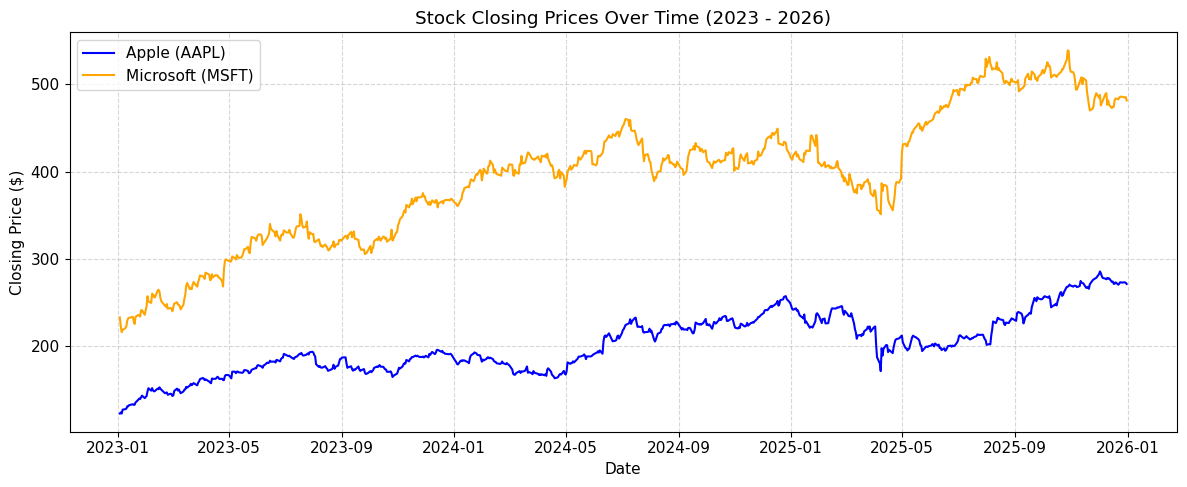

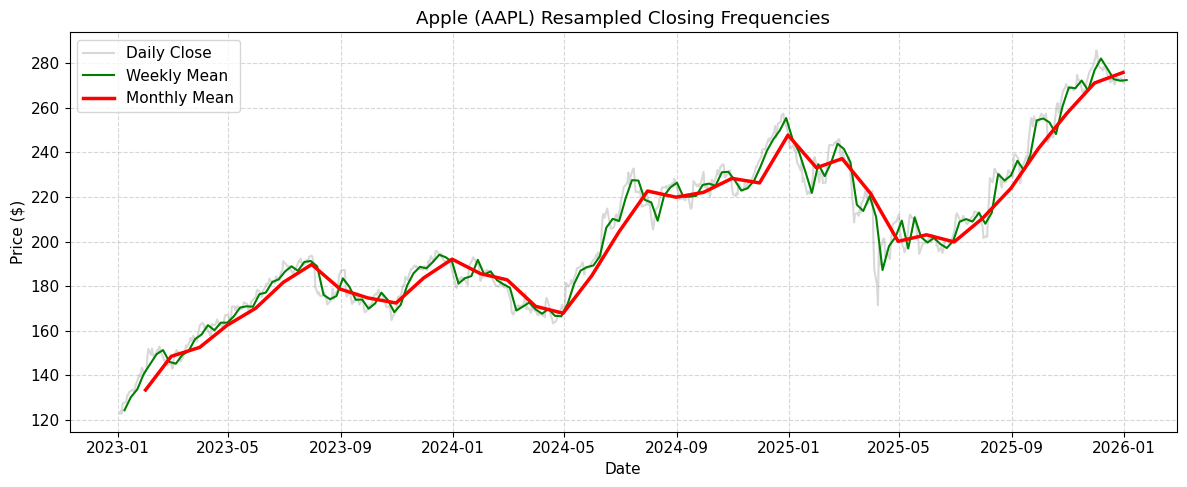

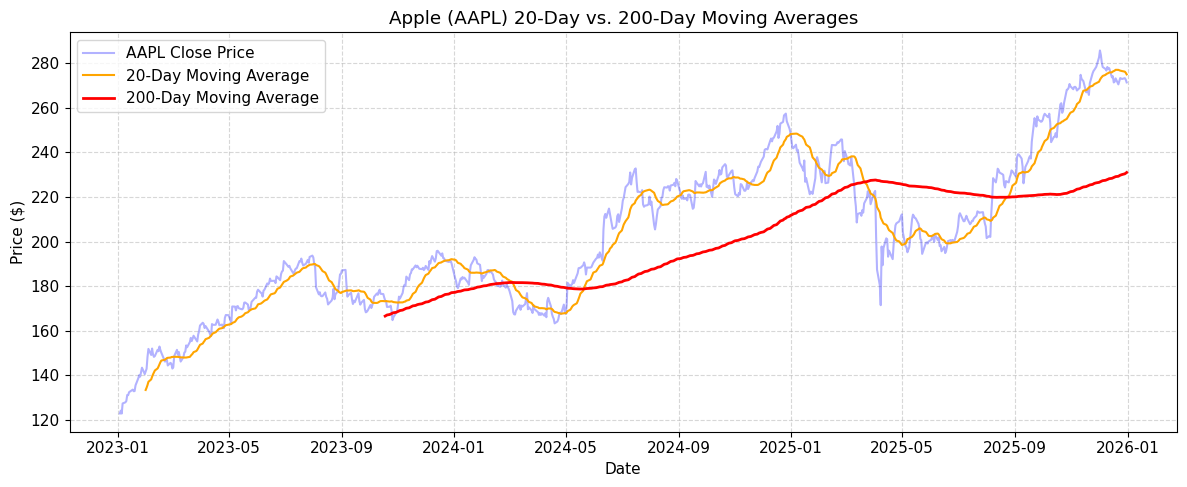

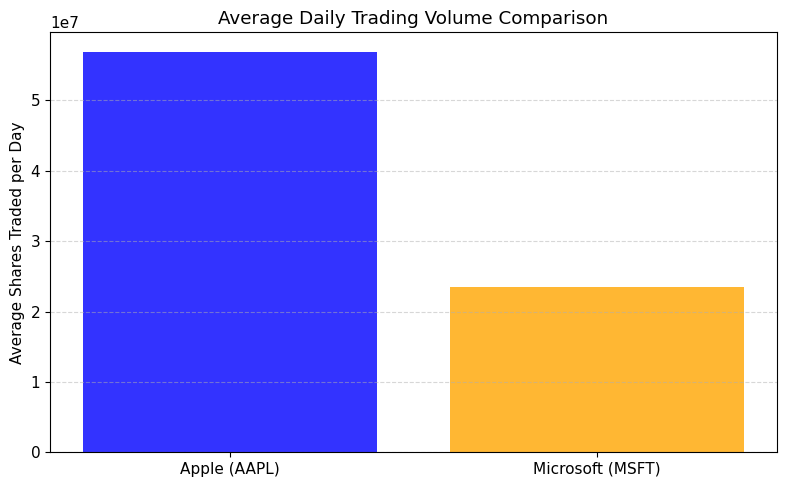

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

# 1. Setup clean styles and inline rendering
%matplotlib inline
plt.rcParams.update({"font.size": 11, "figure.figsize": (12, 6)})

# 2. Download data sequentially to prevent database conflict locks
print("Downloading Apple data...")
aapl_raw = yf.download("AAPL", start="2023-01-01", end="2026-01-01")

print("Downloading Microsoft data...")
msft_raw = yf.download("MSFT", start="2023-01-01", end="2026-01-01")


# 3. Clean up recent yfinance MultiIndex columns to get simple Series/DataFrames
def clean_columns(df):
    df = df.copy()
    # Flatten multi-level headers if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.index = pd.to_datetime(df.index)
    return df


aapl = clean_columns(aapl_raw)
msft = clean_columns(msft_raw)

print("\nData successfully repaired and ready for analysis!")
print(aapl[["Close", "Volume"]].head())

# CHART 1: Closing Prices Over Time

plt.figure(figsize=(12, 5))
plt.plot(aapl.index, aapl["Close"], label="Apple (AAPL)", color="blue")
plt.plot(msft.index, msft["Close"], label="Microsoft (MSFT)", color="orange")
plt.title("Stock Closing Prices Over Time (2023 - 2026)")
plt.xlabel("Date")
plt.ylabel("Closing Price ($)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# CHART 2: Resampled Frequencies
aapl_close_series = aapl["Close"].squeeze()

# Compute resampling frequencies using up-to-date pandas codes
aapl_weekly = aapl_close_series.resample("W").mean()
aapl_monthly = aapl_close_series.resample(
    "ME"
).mean() 
plt.figure(figsize=(12, 5))
plt.plot(
    aapl.index,
    aapl_close_series,
    label="Daily Close",
    alpha=0.3,
    color="gray",
)
plt.plot(aapl_weekly.index, aapl_weekly, label="Weekly Mean", color="green")
plt.plot(
    aapl_monthly.index,
    aapl_monthly,
    label="Monthly Mean",
    color="red",
    linewidth=2.5,
)
plt.title("Apple (AAPL) Resampled Closing Frequencies")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# CHART 3: Moving Averages
aapl["MA20"] = aapl_close_series.rolling(window=20).mean()
aapl["MA200"] = aapl_close_series.rolling(window=200).mean()

plt.figure(figsize=(12, 5))
plt.plot(
    aapl.index,
    aapl_close_series,
    label="AAPL Close Price",
    color="blue",
    alpha=0.3,
)
plt.plot(aapl.index, aapl["MA20"], label="20-Day Moving Average", color="orange")
plt.plot(
    aapl.index, aapl["MA200"], label="200-Day Moving Average", color="red", linewidth=2
)
plt.title("Apple (AAPL) 20-Day vs. 200-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# CHART 4: Trading Volume Comparison

plt.figure(figsize=(8, 5))
plt.bar(
    ["Apple (AAPL)", "Microsoft (MSFT)"],
    [aapl["Volume"].mean(), msft["Volume"].mean()],
    color=["blue", "orange"],
    alpha=0.8,
)
plt.title("Average Daily Trading Volume Comparison")
plt.ylabel("Average Shares Traded per Day")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
